In [1]:
import os
import glob
import gc
import random
import re

import numpy as np
import pandas as pd

import torch

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvi

import pegasus as pg
from pegasusio import UnimodalData

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

torch.set_float32_matmul_precision("high")

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [2]:
## Read In Data ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata.h5ad')
adata_hvg = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_hvg.h5ad', backed='r')

adata.obsm = adata_hvg.obsm.copy()
adata.obsp = adata_hvg.obsp.copy()
adata.uns = adata_hvg.uns.copy()

# collect memory
del adata_hvg
gc.collect()

# read in cluster identites from hierarchical_clustering_scVI  
cluster_identities = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/iterative_clustering_table.csv', index_col=0)
del adata.obs['class']
adata.obs = adata.obs.merge(cluster_identities, left_index=True, right_index=True, how='left')

In [3]:
def subcluster_scvi_per_cluster(adata, class_label="class", new_class_label="subclass",
                                resolution=0.2, n_hvg=3000, max_epochs=20, min_cells_per_cluster=50, 
                                min_donors_per_cluster=3, min_cells_per_batch=10, umap=False):
    
    """
    Subcluster SCVI latent space per cluster, robust to small clusters and tiny batches.

    Parameters
    ----------
    adata : AnnData
        Input AnnData object.
    class_label : str
        Column in adata.obs indicating parent clusters.
    new_class_label : str
        Column name for the resulting subclusters.
    resolution : float
        Leiden clustering resolution.
    n_hvg : int
        Number of highly variable genes to select (clamped to available genes).
    max_epochs : int
        Maximum SCVI training epochs.
    min_cells_per_cluster : int
        Skip clusters smaller than this number of cells.
    min_donors_per_cluster : int
        Skip clusters with fewer donors than this.
    min_cells_per_batch : int
        Minimum cells per batch to include batch_key in HVG selection.
    """

    adata.obs[new_class_label] = pd.Series(index=adata.obs_names, dtype="object")

    for parent in sorted(adata.obs[class_label].unique()):

        print(f"\nSubclustering parent: {parent}")
        mask = adata.obs[class_label] == parent
        adata_cluster = adata[mask].copy()
        n_cells = adata_cluster.n_obs
        n_donors = adata_cluster.obs["Donor"].nunique()

        # Skip clusters that are too small or only have 1 donor
        if n_cells < min_cells_per_cluster or n_donors < min_donors_per_cluster:
            print(f"Skipping cluster {parent}: {n_cells} cells, {n_donors} donor(s)")
            adata.obs.loc[mask, new_class_label] = str(parent) + "_0"
            continue

        print("Cells:", n_cells)
        print("Donors:", n_donors)
        print("Manuscripts:", adata_cluster.obs["Manuscript"].nunique())

        # --- Determine which manuscripts meet the min_cells_per_batch threshold ---
        batch_counts = adata_cluster.obs["Manuscript"].value_counts()
        valid_batches = batch_counts[batch_counts >= min_cells_per_batch].index
        adata_cluster_valid = adata_cluster[adata_cluster.obs["Manuscript"].isin(valid_batches)].copy()

        if valid_batches.shape[0] != batch_counts.shape[0]:
            print("Insufficient Cells Coming From Some Manuscripts, Removing Them For HVG Calculation")
            print(f"Batch Counts are {batch_counts.shape[0]} and Valid Batches are {valid_batches.shape[0]}")


        # ---- Restrict HVG Calculation to the Robust Protein Coding Autosome --- 
        adata_cluster_valid = adata_cluster_valid[:,adata_cluster_valid.var.robust_protein_coding_autosome].copy()
        
        # --- HVG selection only on the valid manuscripts ---
        sc.pp.highly_variable_genes(adata_cluster_valid, layer="log1p_norm", n_top_genes=n_hvg, batch_key="Manuscript", subset=True)

        # --- Get the selected HVGs ---
        hvg_genes = adata_cluster_valid.var[adata_cluster_valid.var['highly_variable']].index

        # --- Now, apply the HVG selection to the full cluster (adata_cluster) ---
        adata_cluster = adata_cluster[:, hvg_genes].copy()

        # --- SCVI setup & training ---
        scvi.model.SCVI.setup_anndata(
            adata_cluster,
            layer="raw_counts",
            categorical_covariate_keys=["Donor", "Manuscript", "Sex"],
            continuous_covariate_keys=["n_counts", "percent_mito"])

        model = scvi.model.SCVI(adata_cluster, n_hidden=512, n_latent=20, n_layers=2)

        model.train(max_epochs=max_epochs, early_stopping=True, batch_size=1024)

        # --- Get latent representation ---
        adata_cluster.obsm["scVI"] = model.get_latent_representation()

        # --- Leiden clustering ---
        adata_cluster = UnimodalData(adata_cluster)
        pg.neighbors(adata_cluster, rep='scVI', use_cache=False, dist='l2', K=100, n_comps=30)
        pg.leiden(adata_cluster, rep="scVI", resolution=resolution, class_label=new_class_label)

        # --- Assign hierarchical labels ---
        hierarchical_labels = str(parent) + "_" + adata_cluster.obs[new_class_label].astype(str)
        adata.obs.loc[mask, new_class_label] = hierarchical_labels.values

        if umap:
            assert adata.obs[class_label].nunique() == 1, \
                "UMAP transfer only works when adata contains a single parent cluster"
            pg.umap(adata_cluster, rep='scVI', n_neighbors=15, rep_ncomps=30)
            adata.obsm["X_umap"] = adata_cluster.obsm["X_umap"]

        # --- Clean up memory ---
        del model
        del adata_cluster
        del adata_cluster_valid
        gc.collect()

    return adata

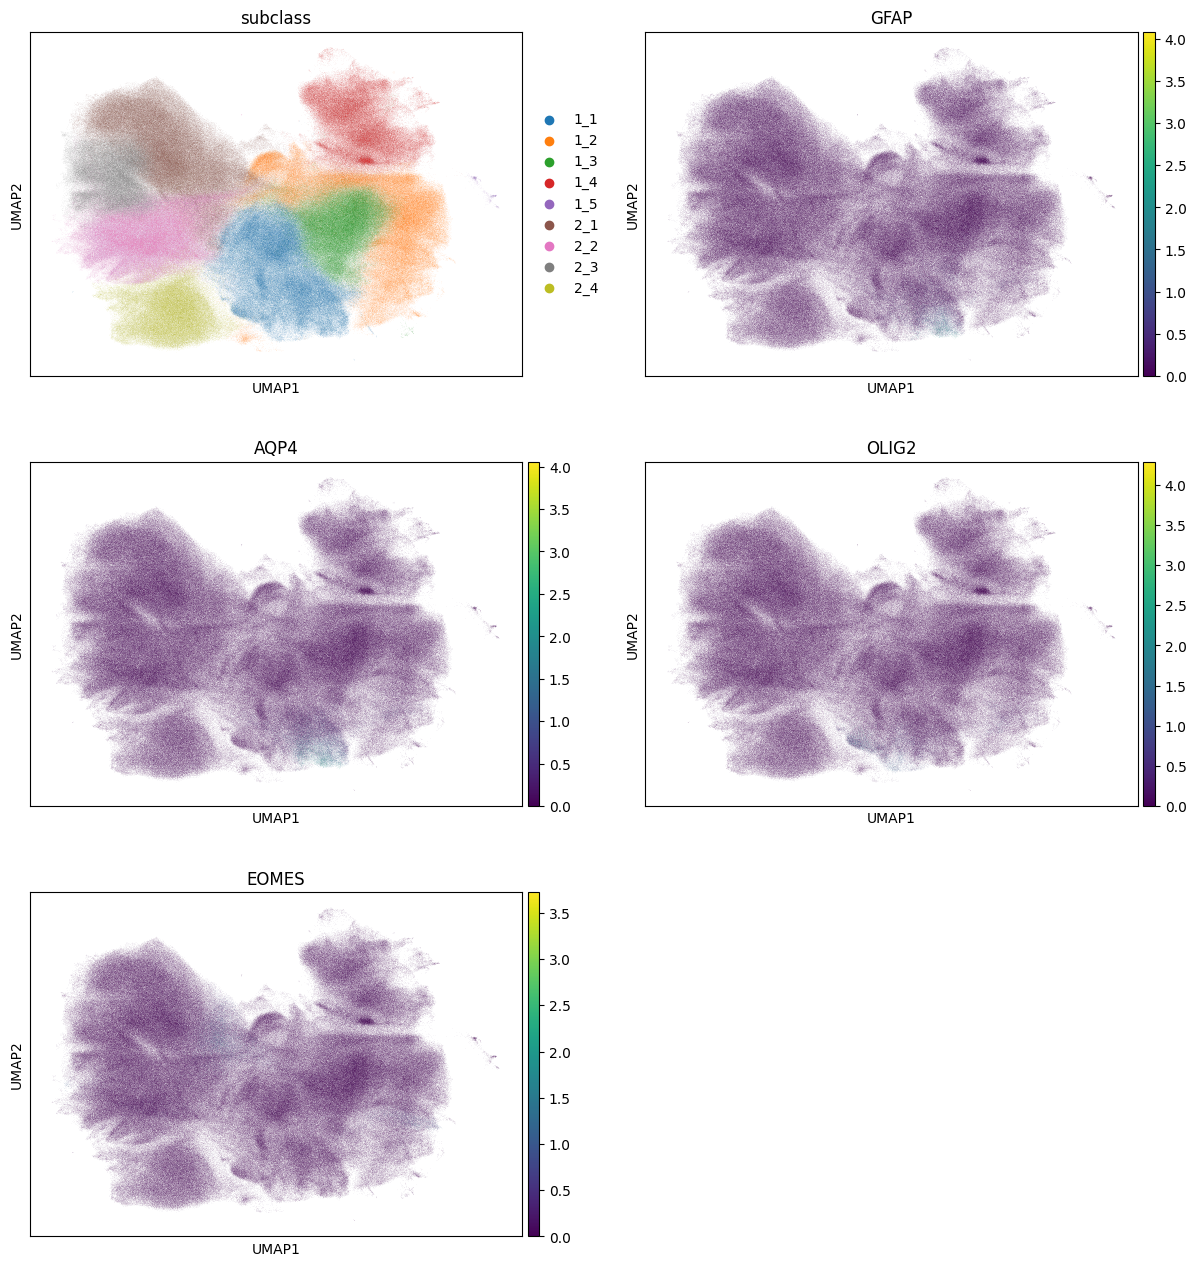

In [4]:
# Find Missing Populations #

sc.pl.umap(adata, color=['subclass', 'GFAP', 'AQP4', 'OLIG2', 'EOMES'], ncols=2)

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


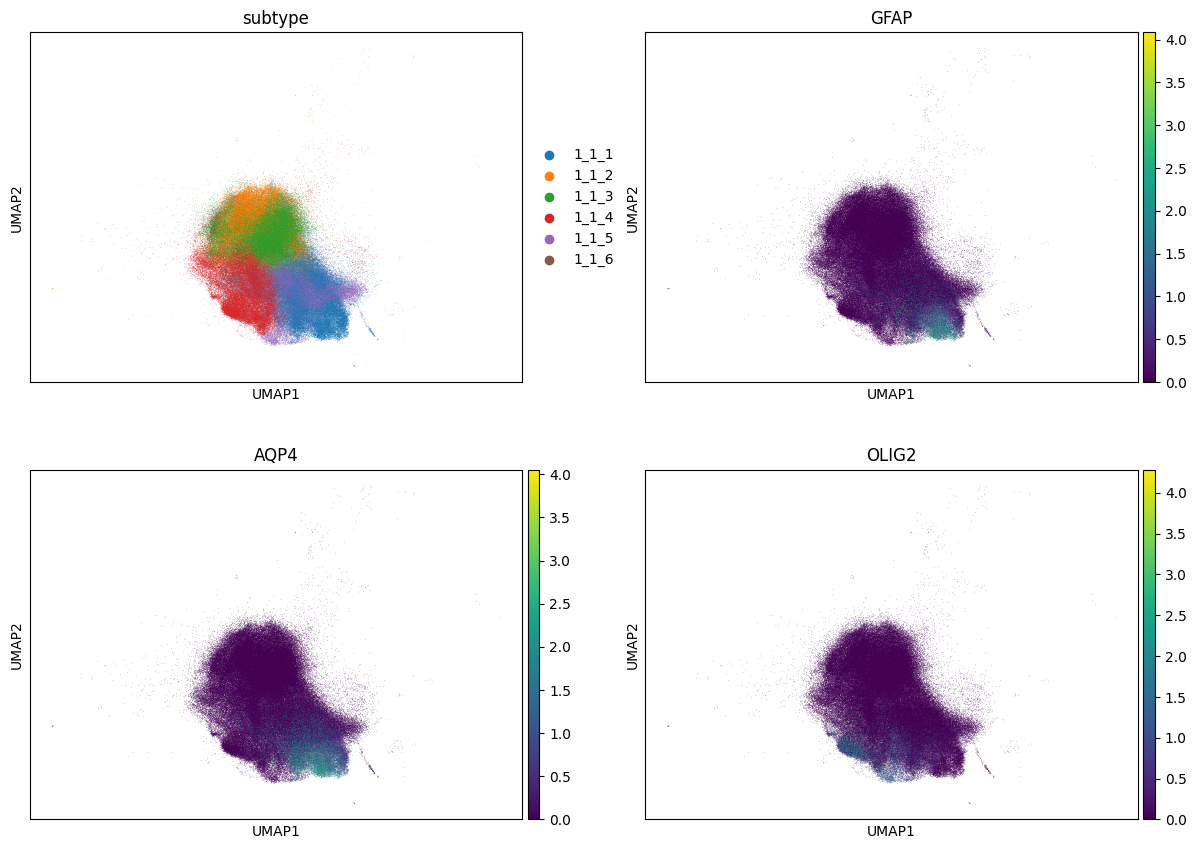

In [5]:
## Subsetting Out Astrocytes and Oligodendrocytes ##

# Visual reveals they are inside 1_1 #
# astrocytes are in 1_1_1
# oligos are in 1_1_4

sc.pl.umap(adata[adata.obs['subclass'] == '1_1'], color=['subtype', 'GFAP', 'AQP4', 'OLIG2'], ncols=2)

In [6]:
## Subsetting Out Astrocytes and Oligodendrocytes ##

# isolate 1_1_1
adata_1_1_1 = adata[adata.obs['subtype'].str.contains('1_1_1')].copy()

# subcluster #
adata_1_1_1 = subcluster_scvi_per_cluster(adata_1_1_1, class_label="subtype", new_class_label="subtype_level_2",
                                resolution=0.3, n_hvg=500, max_epochs=20, min_cells_per_cluster=50, 
                                min_donors_per_cluster=3, min_cells_per_batch=10, umap=True)

# write new cluster labels on adata object
adata.obs['subtype_level_2'] = adata.obs['subtype'].astype('str')
adata.obs['subtype'] = adata.obs['subtype'].astype('str')
adata.obs.loc[adata.obs['subtype'] == '1_1_1', 'subtype_level_2'] = adata_1_1_1.obs['subtype_level_2'].astype('str')

# save memory
gc.collect()


Subclustering parent: 1_1_1
Cells: 63788
Donors: 40
Manuscripts: 9


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 20 in adata.obs['Donor'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/model/_scvi.py:159: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


2026-03-15 22:46:44,634 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 4.81s.
2026-03-15 22:46:45,681 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 1.05s.
2026-03-15 22:46:46,767 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 1.09s.
2026-03-15 22:46:57,458 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 3 clusters.
2026-03-15 22:46:57,495 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 11.81s.
2026-03-15 22:46:57,501 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2026-03-15 22:46:57,501 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.5, n_jobs=1, precomputed_knn=(array([[    0, 20380, 58423, ..., 18773, 2600, 8853],
       [    1, 20381, 14098, ..., 3588, 37523, 14089],
       [    2, 20382, 11061, ..., 34317, 37513, 24144],
       ...

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sun Mar 15 22:46:59 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun Mar 15 22:47:19 2026 Finished embedding
2026-03-15 22:47:19,773 - pegasus.tools.visualization - INFO - Function 'umap' finished in 22.27s.


29

In [7]:
pd.Series(adata_1_1_1.var[adata_1_1_1.var.highly_variable_features].index).str.contains('GFAP').any()

True

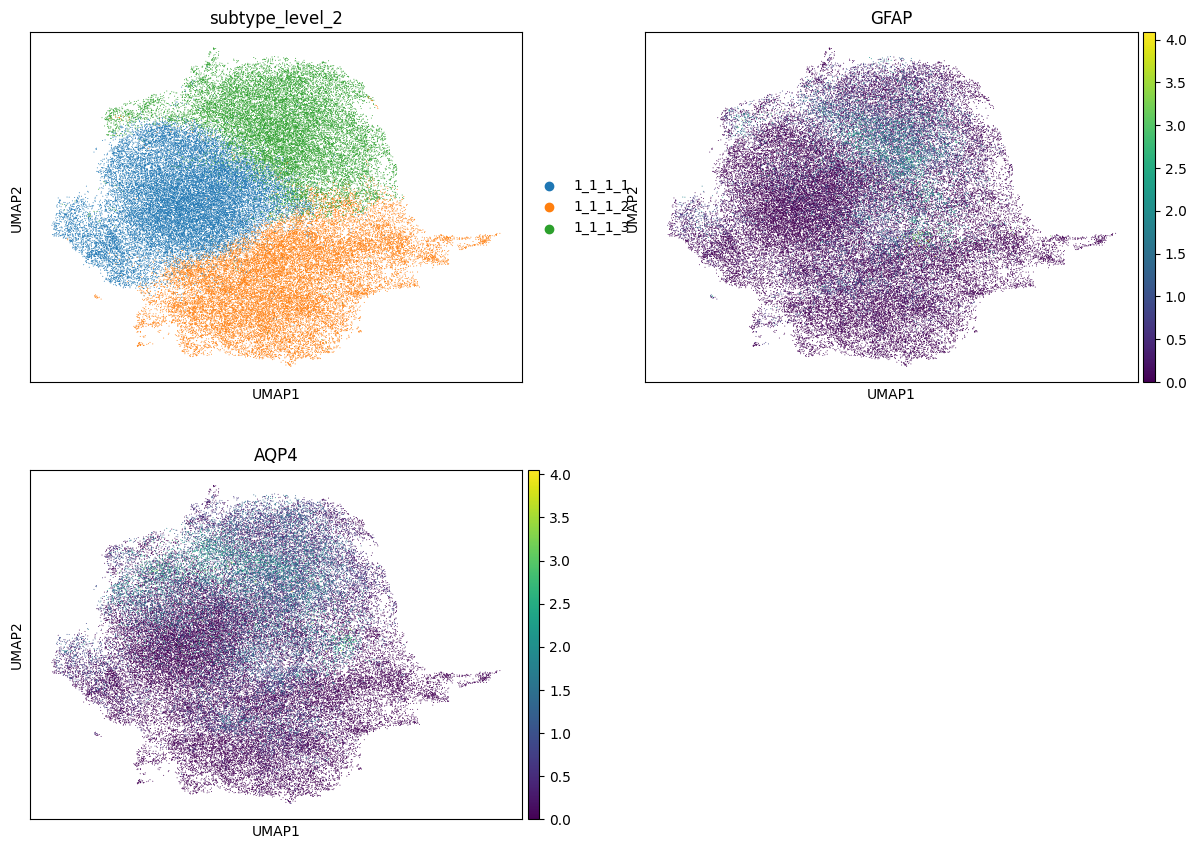

In [8]:
# Reveals Astrocytes Within adata_1_1_1 ##

sc.pl.umap(adata_1_1_1, color=['subtype_level_2', 'GFAP', 'AQP4'], ncols=2)

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


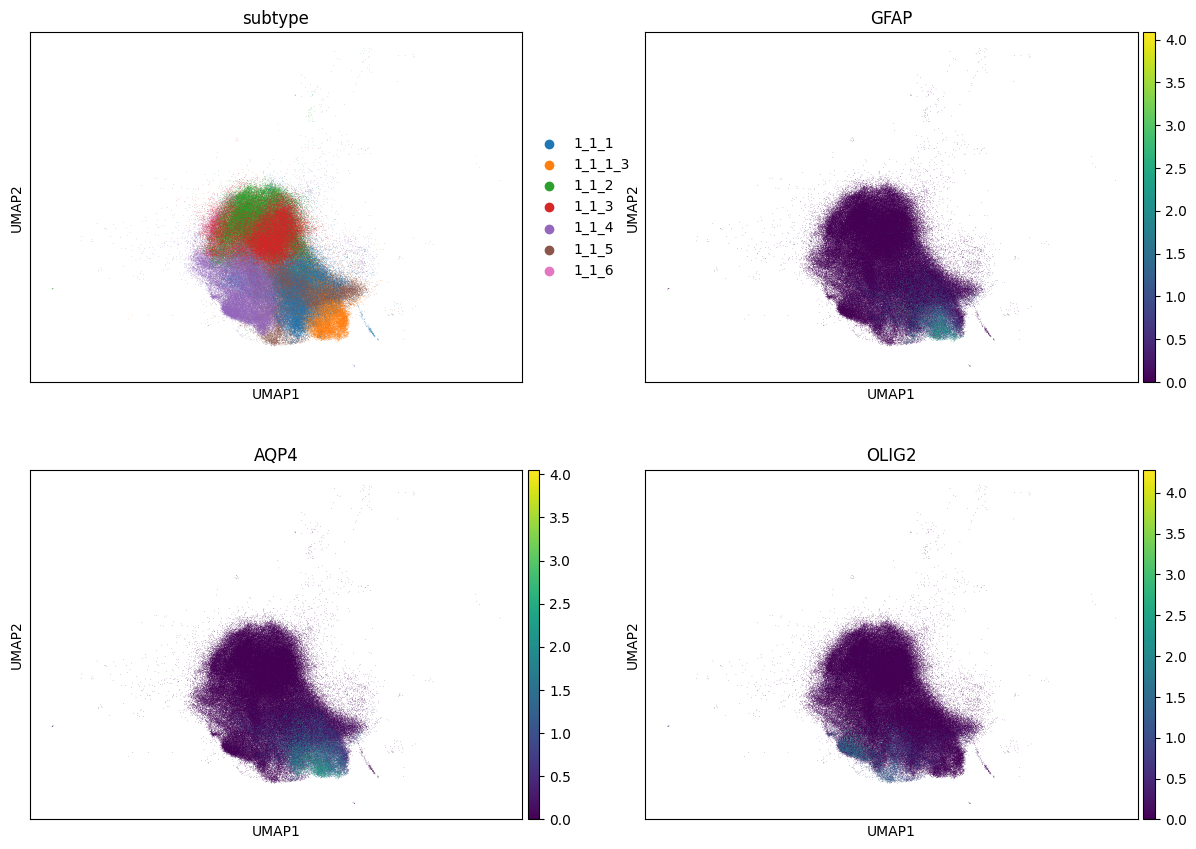

In [9]:
## Write Back Into Adata and Visualize ##

# write 1_1_1_3 subclusters back into anndata object
adata.obs.loc[adata.obs['subtype_level_2'] == '1_1_1_3', 'subtype'] = adata.obs['subtype_level_2'].astype('str')

# visualize 1_1_1_3 back in original scVI space
sc.pl.umap(adata[adata.obs['subtype'].str.contains('^1_1')], color=['subtype', 'GFAP', 'AQP4', 'OLIG2'], ncols=2)

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


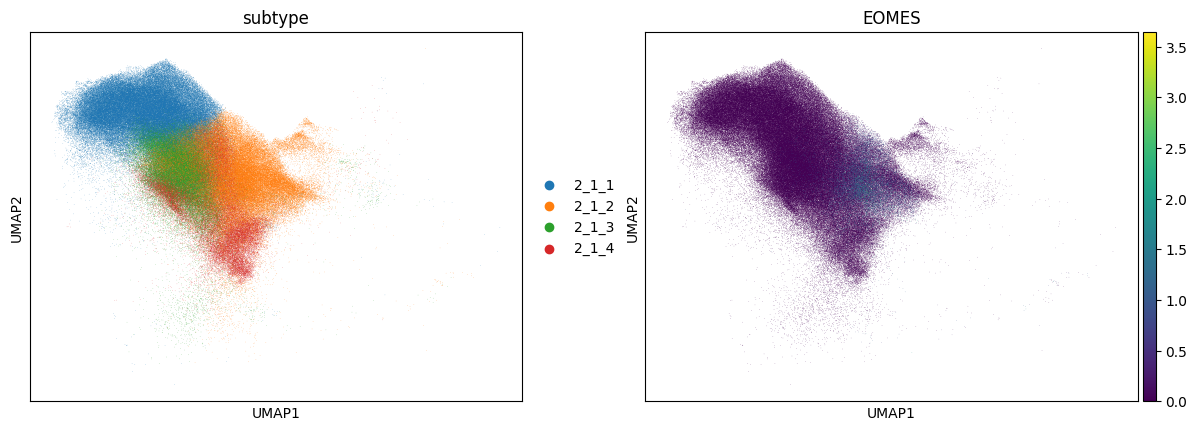

In [10]:
## Subsetting Out IPCs ##

# reveals IPCs within 2_1 

sc.pl.umap(adata[adata.obs['subclass'] == '2_1'], color=['subtype', 'EOMES'])

In [ ]:
## Subsetting Out IPCs Continued ##

# isolate 
adata_2_1_2 = adata[adata.obs['subtype'] == '2_1_2'].copy()

# subcluster adata_2_1_2
adata_2_1_2 = subcluster_scvi_per_cluster(adata_2_1_2, class_label="subtype", new_class_label="subtype_level_2",
                                resolution=0.3, n_hvg=500, max_epochs=20, min_cells_per_cluster=50, 
                                min_donors_per_cluster=3, min_cells_per_batch=10, umap=True)

# write adata_2_1_2 subclusters back into anndata object
adata.obs['subtype_level_2'] = adata.obs['subtype'].astype('str')
adata.obs.loc[adata.obs['subtype'] == '2_1_2', 'subtype_level_2'] = adata_2_1_2.obs['subtype_level_2'].astype('str')


Subclustering parent: 2_1_2
Cells: 82735
Donors: 40
Manuscripts: 9


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 27 in adata.obs['Donor'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/model/_scvi.py:159: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [ ]:
# visualize 
sc.pl.umap(adata_2_1_2, color=['subtype_level_2', 'EOMES'])

In [ ]:
# visualization reveals 2_1_2_2 as most likely EOMES+ cluster 
adata.obs['subtype'] = adata.obs['subtype'].astype('str')
adata.obs.loc[adata.obs['subtype_level_2'] == '2_1_2_2', 'subtype'] = adata_2_1_2.obs['subtype_level_2'].astype('str')

In [ ]:
# Post Subclustering #
adata.obs['subtype'] = adata.obs['subtype'].astype('str')
sc.pl.umap(adata, color='subtype')

In [ ]:
## Save ##

adata.obs[['class', 'subclass', 'subtype']].to_csv('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/iterative_clustering_table_plus_missing.csv')